### ROC-AUC Model Evaluation

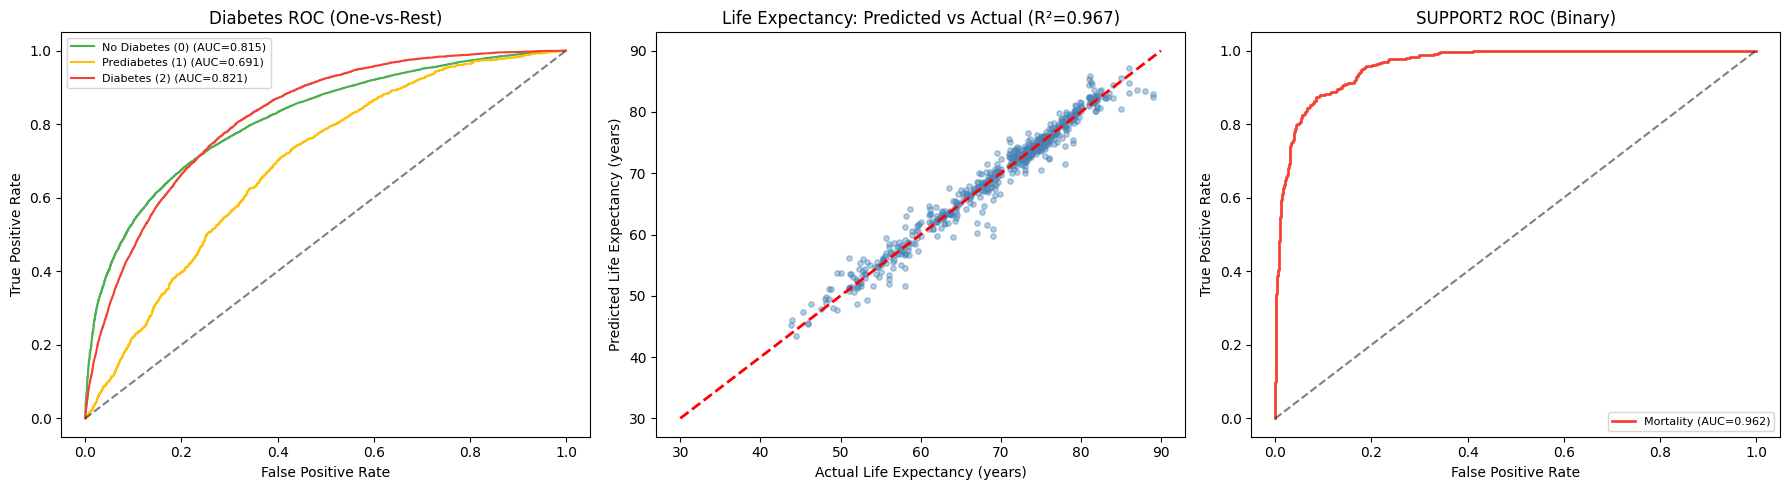

In [1]:
# Run this notebook — generates 3 performance plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, label_binarize
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_curve, auc, r2_score

#1. DIABETES ROC (One-vs-Rest)
df_diab = pd.read_csv("diabetes_no_duplicates.csv")
X_d = df_diab.drop(columns=["Diabetes_012"])
y_d = df_diab["Diabetes_012"].astype(int)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, stratify=y_d, random_state=42)

gb_d = GradientBoostingClassifier(
    learning_rate=0.05, n_estimators=100, max_depth=3,
    min_samples_leaf=20, subsample=0.9, random_state=42)
gb_d.fit(X_train_d, y_train_d)

y_prob_d = gb_d.predict_proba(X_test_d)
y_bin_d = label_binarize(y_test_d, classes=[0, 1, 2])

#2. LIFE EXPECTANCY Predicted vs Actual
df_le = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv")
df_le.columns = df_le.columns.str.strip()
le_num = df_le.select_dtypes(include=[np.number])
X_le = le_num.drop(columns=["Life expectancy"])
y_le = le_num["Life expectancy"]

X_train_le, X_test_le, y_train_le, y_test_le = train_test_split(
    X_le, y_le, test_size=0.2, random_state=42)

scaler_le = StandardScaler()
X_train_le_s = scaler_le.fit_transform(X_train_le)
X_test_le_s = scaler_le.transform(X_test_le)

gb_le = GradientBoostingRegressor(
    learning_rate=0.2, n_estimators=600, max_depth=5,
    min_samples_leaf=10, random_state=42)
gb_le.fit(X_train_le_s, y_train_le)
y_pred_le = gb_le.predict(X_test_le_s)

#3. SUPPORT2 ROC (Binary)
df_s2 = pd.read_csv("support2_imputed.csv")
s2_num = df_s2.select_dtypes(include=[np.number])
X_s2 = s2_num.drop(columns=["hospdead"])
y_s2 = s2_num["hospdead"].astype(int)

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_s2, y_s2, test_size=0.2, stratify=y_s2, random_state=42)

scaler_s2 = StandardScaler()
X_train_s2_s = scaler_s2.fit_transform(X_train_s2)
X_test_s2_s = scaler_s2.transform(X_test_s2)

gb_s2 = GradientBoostingClassifier(
    learning_rate=0.2, n_estimators=100, max_depth=3,
    min_samples_leaf=20, subsample=1.0, random_state=42)
gb_s2.fit(X_train_s2_s, y_train_s2)
y_prob_s2 = gb_s2.predict_proba(X_test_s2_s)[:, 1]

#PLOT ALL THREE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Diabetes ROC (One-vs-Rest)
colors = ['#4CAF50', '#FFC107', '#F44336']
labels = ['No Diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin_d[:, i], y_prob_d[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i], label=f'{labels[i]} (AUC={roc_auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Diabetes ROC (One-vs-Rest)')
axes[0].legend(fontsize=8)

# Panel 2: Life Expectancy Predicted vs Actual
r2 = r2_score(y_test_le, y_pred_le)
axes[1].scatter(y_test_le, y_pred_le, alpha=0.4, s=15, color='steelblue')
axes[1].plot([30, 90], [30, 90], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Life Expectancy (years)')
axes[1].set_ylabel('Predicted Life Expectancy (years)')
axes[1].set_title(f'Life Expectancy: Predicted vs Actual (R²={r2:.3f})')

# Panel 3: SUPPORT2 ROC (Binary)
fpr_s2, tpr_s2, _ = roc_curve(y_test_s2, y_prob_s2)
roc_auc_s2 = auc(fpr_s2, tpr_s2)
axes[2].plot(fpr_s2, tpr_s2, color='#F44336', linewidth=2,
             label=f'Mortality (AUC={roc_auc_s2:.3f})')
axes[2].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('SUPPORT2 ROC (Binary)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()